# Image-Reliance Report — model comparison (CocoFreeView test split)

Compares the image-reliance diagnostics across **four model versions**:

| key | version | source | fix / eye layers |
|---|---|---|---|
| `prev` | **Previous model** | printed table pasted from `20260730173817.png` (residual norms only) | 4 / 4 |
| `256`  | **New image encoder @ 256 px** | `Output/image_reliance/mask2former_ms_reliance.h5` | 4 / 4 |
| `512`  | **New image encoder @ 512 px** | `Output/image_relianceL/mask2former_ms_reliance.h5` | 3 / 3 |
| `512D` | **512 px + path-dropout** | `Output/image_reliance_drop/image_reliance_drop/mask2former_ms_reliance.h5` | 3 / 3 |

The per-sample store is written by [`src/notebooks/save_image_reliance.py`](../notebooks/save_image_reliance.py).
Diagnostics reported, **whenever the data allows a comparison**:

1. **Regression error** on the test set — *clean* vs *image-shuffled* run &nbsp;→&nbsp; `256` / `512` / `512D`
   (the previous run did not persist a perturbation pass).
2. **Deformable sampling in-range %** — every (module × layer × resolution) &nbsp;→&nbsp; `256` / `512` / `512D`
   (deformable in-range was not captured for the previous run).
4. **Deformable cross-attention residual norms** per layer &nbsp;→&nbsp; **all versions**
   (the one diagnostic available for every version, including the pasted table).

*Notes.* The previous model exposes **only** residual norms (from the pasted table), so it appears
only in section 4. Layer counts differ (prev/256 = 4, 512/512D = 3) and the per-level resolutions differ
(256 → 8/16/32, 512/512D → 16/32/64), so comparisons are drawn per layer-index / per level-index and these
caveats are flagged inline. Regression error is stored **normalised** to `[0,1]`; the fair
cross-resolution number is the normalised error (or the relative shuffle penalty), **not** pixels —
both are shown.

*(Section 3 — arrow plots of where deformable attention points — is intentionally omitted: the raw
`sampling_locations`, image pixels, and fixation coordinates it needs were not persisted; only the
aggregated in-range fraction was.)*

## Setup

In [26]:
import os
import json
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.axisbelow": True, "font.size": 10})

# ── Per-version colours (consistent across every plot) ──
COLORS = {"prev": "#7570b3", "256": "#2c7fb8", "512": "#d95f0e", "512D": "#31a354"}

# ── Human-readable labels (512 and 512D share img_size, so label them apart) ──
LABELS = {"256": "New encoder @ 256px", "512": "New encoder @ 512px",
          "512D": "512px + path-dropout"}

# ── Locate the stores (works from src/notebooks or the project root) ──
def _find(*cands):
    return next((p for p in cands if os.path.exists(p)), cands[0])

H5 = {
    "256": _find(os.path.join("Output", "image_reliance",  "mask2former_ms_reliance.h5"),
                 os.path.join("..", "..", "Output", "image_reliance",  "mask2former_ms_reliance.h5")),
    "512": _find(os.path.join("Output", "image_relianceL", "mask2former_ms_reliance.h5"),
                 os.path.join("..", "..", "Output", "image_relianceL", "mask2former_ms_reliance.h5")),
    "512D": _find(os.path.join("Output", "image_reliance_drop", "image_reliance_drop", "mask2former_ms_reliance.h5"),
                  os.path.join("..", "..", "Output", "image_reliance_drop", "image_reliance_drop", "mask2former_ms_reliance.h5")),
}
for k, p in H5.items():
    print(f"{k}: {os.path.abspath(p)}   exists={os.path.exists(p)}")

256: c:\Users\ulloa\Miooooo\Master\thesis\Projects\From-Noisy-Eye-Tracking-To-Scanpath\Output\image_reliance\mask2former_ms_reliance.h5   exists=True
512: c:\Users\ulloa\Miooooo\Master\thesis\Projects\From-Noisy-Eye-Tracking-To-Scanpath\Output\image_relianceL\mask2former_ms_reliance.h5   exists=True
512D: c:\Users\ulloa\Miooooo\Master\thesis\Projects\From-Noisy-Eye-Tracking-To-Scanpath\Output\image_reliance_drop\image_reliance_drop\mask2former_ms_reliance.h5   exists=True


In [27]:
# ── Previous-model residual norms, transcribed from the pasted table (20260730173817.png) ──
# Mean residual L2 norm; only residuals were reported for this run (no perturbation, no in-range).
PREV = {
    "label": "Previous model", "img_size": None, "n_dec": 4, "n_eye": 4,
    "fix": {  # fixation decoder, layers 0..3
        "self":  np.array([14.460, 11.525, 17.897, 22.505]),
        "gaze":  np.array([17.133, 20.987, 41.753, 78.502]),   # 1st cross
        "image": np.array([ 6.937, 10.671, 10.371,  8.013]),   # 2nd cross (deformable)
        "ffn":   np.array([10.851, 13.958, 14.673, 17.571]),
    },
    "eye": {  # eye decoder (gaze->image), layers 0..3
        "self":  np.array([17.776, 26.348, 35.323, 27.689]),
        "image": np.array([32.107, 24.890, 22.691, 40.996]),   # cross (deformable)
        "ffn":   np.array([11.707,  8.097,  7.303,  6.591]),
    },
}

In [28]:
# ── Load a store (skip the big float16 full-residual dumps we don't need here) ──
SKIP = {"dec_first_cross_res", "dec_second_cross_res"}   # (N, L, 21, 512) fp16

def load_store(path):
    D, ATTRS = {}, {}
    with h5py.File(path, "r") as f:
        g = f["/reliance"]
        for k in g:
            if k not in SKIP:
                D[k] = g[k][()]
        ATTRS = dict(g.attrs)
    return D, ATTRS

def store_layer_mean(D, key):
    # Mean residual norm per layer, position-POOLED: nanmean over every active
    # (sample, query-position) jointly — matching the pasted table's definition
    # ("over active positions across all samples") and the summary JSON's aggregation.
    arr = D[key]                              # (N, n_layers, T)
    return np.nanmean(arr, axis=(0, 2))       # (n_layers,)

def build_version(key, path):
    D, A = load_store(path)
    ss = np.asarray(A.get("spatial_shapes")).reshape(-1, 2)
    v = {
        "key": key, "label": LABELS.get(key, f"New encoder @ {int(A['img_size'])}px"),
        "D": D, "ATTRS": A,
        "img_size": int(A["img_size"]),
        "n_dec": int(A.get("n_decoder", 4)),
        "n_eye": int(A.get("n_eye_decoder", 4)),
        "level_labels": [f"L{i} ({h}x{w})" for i, (h, w) in enumerate(ss)],
        "n_lvl": len(ss),
        "fix": {
            "self":  store_layer_mean(D, "dec_self_attention_res_norm"),
            "gaze":  store_layer_mean(D, "dec_first_cross_res_norm"),
            "image": store_layer_mean(D, "dec_second_cross_res_norm"),
            "ffn":   store_layer_mean(D, "dec_ffn_res_norm"),
        },
        "eye": {
            "self":  store_layer_mean(D, "eye_self_attention_res_norm"),
            "image": store_layer_mean(D, "eye_cross_attention_res_norm"),
            "ffn":   store_layer_mean(D, "eye_ffn_res_norm"),
        },
    }
    return v

VER = {k: build_version(k, p) for k, p in H5.items()}   # {"256":..., "512":..., "512D":...}
# Previous model participates in residual comparisons only:
PREV["key"], PREV["level_labels"], PREV["n_lvl"] = "prev", None, None

# ── Canonical orderings used by every downstream cell ──
LIVE_KEYS = list(VER)                                 # versions with a per-sample store
RES_VERSIONS = [PREV, *VER.values()]                  # all versions (residual sections)

for k in LIVE_KEYS:
    v = VER[k]
    print(f"[{k}] {v['label']:<22} N={len(v['D']['sample_idx'])}  "
          f"fix_layers={v['n_dec']} eye_layers={v['n_eye']}  levels={v['level_labels']}")
print(f"[prev] {PREV['label']:<21} residual table only  "
      f"fix_layers={PREV['n_dec']} eye_layers={PREV['n_eye']}  (no perturbation / in-range)")

[256] New encoder @ 256px    N=7018  fix_layers=4 eye_layers=4  levels=['L0 (8x8)', 'L1 (16x16)', 'L2 (32x32)']
[512] New encoder @ 512px    N=6991  fix_layers=3 eye_layers=3  levels=['L0 (16x16)', 'L1 (32x32)', 'L2 (64x64)']
[512D] 512px + path-dropout   N=7004  fix_layers=3 eye_layers=3  levels=['L0 (16x16)', 'L1 (32x32)', 'L2 (64x64)']
[prev] Previous model        residual table only  fix_layers=4 eye_layers=4  (no perturbation / in-range)


## 1) Regression error — clean vs. image-shuffled  &nbsp;(`256` vs `512`)

`reg_error_*` is the mean Euclidean distance between predicted and target fixation positions in
**normalised** `[0,1]` coordinates.

- **clean** — the model's own test-set prediction error.
- **shuffled** — same forward, but each image is swapped for another sample's image (gaze untouched).
  If the model relied on the image, this should get worse.

The previous model has no perturbation pass, so it is absent here. Across resolutions the
**normalised** error and the **relative shuffle penalty** (`Δ / clean`) are the fair comparison;
pixel columns use each run's own `img_size` and are shown only for intuition.

In [29]:
def perturb_rows(v):
    D = v["D"]; px = v["img_size"]
    clean = D["reg_error_clean"]; shuf = D["reg_error_shuffled"]
    valid = ~np.isnan(clean) & ~np.isnan(shuf)
    c, s = clean[valid], shuf[valid]
    d = s - c
    return {
        "version": v["label"], "img_size": px, "n_valid": int(valid.sum()),
        "clean_norm":  c.mean(), "shuffled_norm": s.mean(),
        "clean_px":    c.mean() * px, "shuffled_px": s.mean() * px,
        "delta_norm":  d.mean(), "rel_penalty_%": 100 * d.mean() / c.mean(),
        "median_delta_norm": np.median(d), "frac_worse_%": 100 * (d > 0).mean(),
    }

pert = pd.DataFrame([perturb_rows(VER[k]) for k in LIVE_KEYS]).set_index("version")
print("Regression error — clean vs image-shuffled:")
display(pert.round({"clean_norm": 4, "shuffled_norm": 4, "clean_px": 2, "shuffled_px": 2,
                    "delta_norm": 4, "rel_penalty_%": 2, "median_delta_norm": 4, "frac_worse_%": 1}))
print("\nHigher rel_penalty_% / frac_worse_% ⇒ the model leans more on the image.")

Regression error — clean vs image-shuffled:


,img_size,n_valid,clean_norm,shuffled_norm,clean_px,shuffled_px,delta_norm,rel_penalty_%,median_delta_norm,frac_worse_%
version,,,,,,,,,,
New encoder @ 256px,256,7018,0.1219,0.1273,31.209999,32.590000,0.0054,4.43,0.0036,58.1
New encoder @ 512px,512,6991,0.1255,0.1349,64.269997,69.070000,0.0094,7.47,0.0064,59.1
512px + path-dropout,512,7004,0.1196,0.1252,61.259998,64.089996,0.0055,4.62,0.0037,59.6



Higher rel_penalty_% / frac_worse_% ⇒ the model leans more on the image.


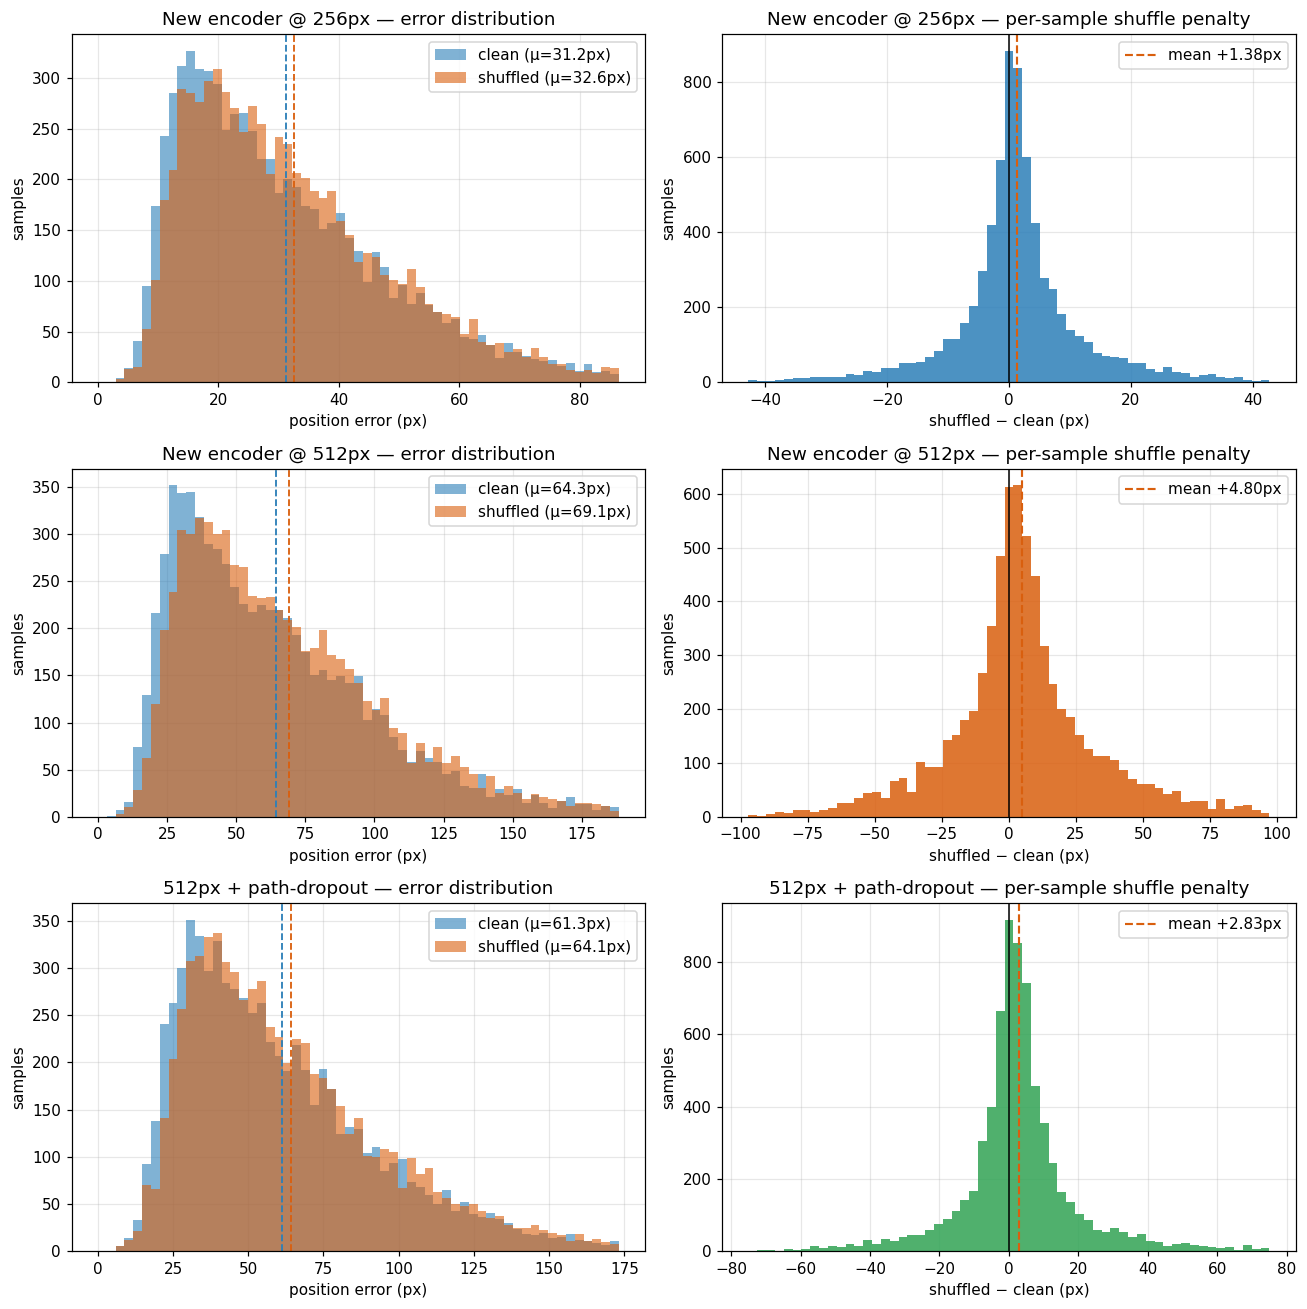

In [30]:
fig, axes = plt.subplots(len(LIVE_KEYS), 2, figsize=(12, 4 * len(LIVE_KEYS)), squeeze=False)
for row, k in enumerate(LIVE_KEYS):
    v = VER[k]; D = v["D"]; px = v["img_size"]
    clean = D["reg_error_clean"] * px; shuf = D["reg_error_shuffled"] * px
    valid = ~np.isnan(clean) & ~np.isnan(shuf)
    c, s = clean[valid], shuf[valid]; d = s - c
    col = COLORS[k]

    ax = axes[row, 0]
    bins = np.linspace(0, np.percentile(np.concatenate([c, s]), 99), 60)
    ax.hist(c, bins=bins, alpha=0.6, label=f"clean (μ={c.mean():.1f}px)", color="#2c7fb8")
    ax.hist(s, bins=bins, alpha=0.6, label=f"shuffled (μ={s.mean():.1f}px)", color="#d95f0e")
    ax.axvline(c.mean(), color="#2c7fb8", ls="--", lw=1.2)
    ax.axvline(s.mean(), color="#d95f0e", ls="--", lw=1.2)
    ax.set(xlabel="position error (px)", ylabel="samples",
           title=f"{v['label']} — error distribution")
    ax.legend()

    ax = axes[row, 1]
    lim = np.percentile(np.abs(d), 99)
    ax.hist(d, bins=np.linspace(-lim, lim, 60), color=col, alpha=0.85)
    ax.axvline(0, color="k", lw=1)
    ax.axvline(d.mean(), color="#d95f0e", ls="--", lw=1.4, label=f"mean {d.mean():+.2f}px")
    ax.set(xlabel="shuffled − clean (px)", ylabel="samples",
           title=f"{v['label']} — per-sample shuffle penalty")
    ax.legend()
plt.tight_layout(); plt.show()

## 2) Deformable sampling in-range %  &nbsp;(`256` vs `512`)

Fraction of deformable sampling locations that land **inside** the `[0,1]` feature map (locations
outside are zero-padded by `grid_sample`, wasting attention weight). Stored per sample as
`dec_inrange` / `eye_inrange`, each shaped `(N, n_layers, 3 resolutions)`.

Not captured for the previous model. Note the per-level resolutions differ between runs
(256 → 8/16/32, 512 → 16/32/64), so the level **index** is comparable but the absolute map size is not.

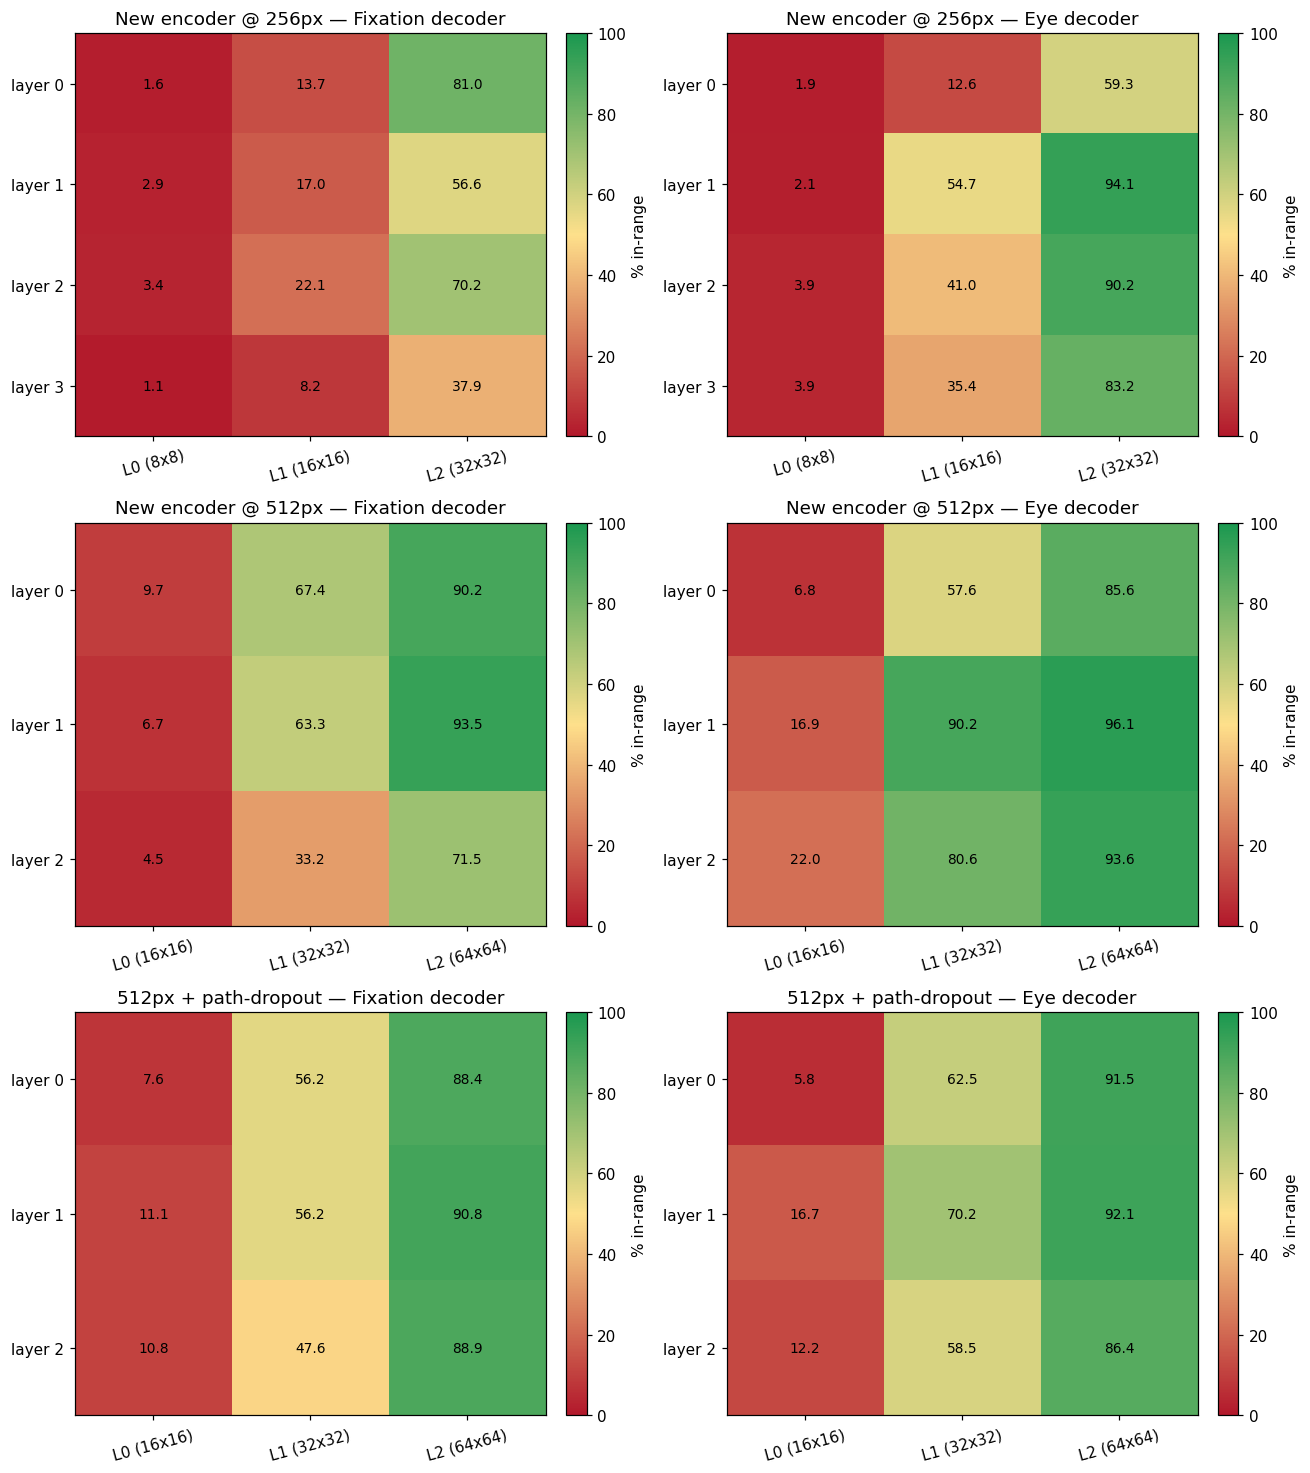

In [31]:
cmap = LinearSegmentedColormap.from_list("gyr", ["#b2182b", "#fee08b", "#1a9850"])

# One row of heatmaps per version: [fixation decoder | eye decoder], shared 0..100 scale.
fig, axes = plt.subplots(len(LIVE_KEYS), 2, figsize=(12, 4.5 * len(LIVE_KEYS)), squeeze=False)
for row, k in enumerate(LIVE_KEYS):
    v = VER[k]; D = v["D"]; LL = v["level_labels"]; nlvl = v["n_lvl"]
    for col, (name, ir_key, nl) in enumerate(
            [("Fixation decoder", "dec_inrange", v["n_dec"]),
             ("Eye decoder", "eye_inrange", v["n_eye"])]):
        ir = D[ir_key] * 100.0
        M = np.nanmean(ir, axis=0)                    # (layers, levels)
        ax = axes[row, col]
        im = ax.imshow(M, cmap=cmap, vmin=0, vmax=100, aspect="auto")
        ax.set_xticks(range(nlvl)); ax.set_xticklabels(LL, rotation=15)
        ax.set_yticks(range(nl));   ax.set_yticklabels([f"layer {i}" for i in range(nl)])
        ax.set_title(f"{v['label']} — {name}"); ax.grid(False)
        for i in range(nl):
            for j in range(nlvl):
                ax.text(j, i, f"{M[i,j]:.1f}", ha="center", va="center", fontsize=9)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="% in-range")
plt.tight_layout(); plt.show()

In [32]:
# ── Full table: one row per (version, module, layer, resolution-index) ──
rows = []
for k in LIVE_KEYS:
    v = VER[k]; D = v["D"]; LL = v["level_labels"]
    for name, ir_key, nl in [("Fixation decoder", "dec_inrange", v["n_dec"]),
                             ("Eye decoder", "eye_inrange", v["n_eye"])]:
        ir = D[ir_key] * 100.0
        for l in range(nl):
            for j in range(v["n_lvl"]):
                col = ir[:, l, j]; col = col[~np.isnan(col)]
                rows.append({"version": v["label"], "module": name, "layer": l,
                             "resolution": LL[j], "mean_%": col.mean(),
                             "median_%": np.median(col), "std_%": col.std()})
ir_tbl = pd.DataFrame(rows).round(2)
display(ir_tbl.style.hide(axis="index")
        .background_gradient(cmap="RdYlGn", vmin=0, vmax=100, subset=["mean_%"]))

version,module,layer,resolution,mean_%,median_%,std_%
New encoder @ 256px,Fixation decoder,0,L0 (8x8),1.600000,1.560000,0.690000
New encoder @ 256px,Fixation decoder,0,L1 (16x16),13.700000,13.620000,2.120000
New encoder @ 256px,Fixation decoder,0,L2 (32x32),81.000000,81.250000,2.520000
New encoder @ 256px,Fixation decoder,1,L0 (8x8),2.920000,2.900000,0.970000
New encoder @ 256px,Fixation decoder,1,L1 (16x16),16.959999,17.070000,1.870000
New encoder @ 256px,Fixation decoder,1,L2 (32x32),56.650002,57.080002,4.480000
New encoder @ 256px,Fixation decoder,2,L0 (8x8),3.370000,3.320000,1.180000
New encoder @ 256px,Fixation decoder,2,L1 (16x16),22.120001,22.080000,3.010000
New encoder @ 256px,Fixation decoder,2,L2 (32x32),70.180000,70.419998,3.940000
New encoder @ 256px,Fixation decoder,3,L0 (8x8),1.130000,1.040000,0.780000


## 4) Deformable cross-attention residual norms per layer  &nbsp;(**all three versions**)

The residual each cross-attention block adds to the stream (L2 norm over the feature dim, averaged
over decode steps and samples). The **deformable (image) cross-attention** is the stream of interest:

- **Fixation decoder** — `image` = 2nd cross (deformable); `gaze` = 1st cross; plus self-attn and FFN.
  The headline diagnostic is the **image / gaze** ratio — `<< 1` supports "the image is being ignored".
- **Eye decoder** — `image` = cross (deformable); the reference is the **image / self** ratio.

This is the only diagnostic available for the previous model, so all three versions appear here.
Layer counts differ (prev/256 = 4, 512 = 3); tables are indexed by layer, plots overlay per layer-index.

*Aggregation.* All three versions use the **position-pooled** mean (over every active
(sample, decode-step) jointly) — the definition printed under the pasted previous-model table and
used by `mask2former_ms_summary.json`. For the **eye decoder** this reproduces the summary JSON
exactly; the **fixation-decoder** numbers derived from the persisted store differ from the JSON by
~2–3% (a store-vs-live-pass masking nuance in `save_image_reliance.py`), which does not change the
qualitative ratios.

In [33]:
def fix_table(v):
    f = v["fix"]; n = v["n_dec"]
    df = pd.DataFrame({
        "self": f["self"], "gaze (1st)": f["gaze"], "image (2nd, deform)": f["image"],
        "ffn": f["ffn"], "image/gaze": f["image"] / f["gaze"],
    }, index=[f"layer {i}" for i in range(n)])
    return df

def eye_table(v):
    e = v["eye"]; n = v["n_eye"]
    df = pd.DataFrame({
        "self": e["self"], "image (cross, deform)": e["image"], "ffn": e["ffn"],
        "image/self": e["image"] / e["self"],
    }, index=[f"layer {i}" for i in range(n)])
    return df

for v in RES_VERSIONS:
    print(f"=== {v['label']} — fixation decoder ==="); display(fix_table(v).round(3))
for v in RES_VERSIONS:
    print(f"=== {v['label']} — eye decoder ===");      display(eye_table(v).round(3))

=== Previous model — fixation decoder ===


,self,gaze (1st),"image (2nd, deform)",ffn,image/gaze
layer 0,14.460,17.133,6.937,10.851,0.405
layer 1,11.525,20.987,10.671,13.958,0.508
layer 2,17.897,41.753,10.371,14.673,0.248
layer 3,22.505,78.502,8.013,17.571,0.102


=== New encoder @ 256px — fixation decoder ===


,self,gaze (1st),"image (2nd, deform)",ffn,image/gaze
layer 0,35.324001,29.094999,12.752,43.271999,0.438
layer 1,18.587999,42.929001,13.515,40.316002,0.315
layer 2,33.696999,64.449997,26.309,24.813999,0.408
layer 3,35.182999,156.888000,7.255,36.431000,0.046


=== New encoder @ 512px — fixation decoder ===


...

,self,"image (cross, deform)",ffn,image/self
layer 0,17.075001,3.876000,70.482002,0.227
layer 1,43.261002,39.837002,16.573999,0.921
layer 2,76.111000,32.446999,15.743000,0.426
layer 3,51.519001,64.892998,26.170000,1.260


=== New encoder @ 512px — eye decoder ===


,self,"image (cross, deform)",ffn,image/self
layer 0,10.338000,13.060000,92.195000,1.263
layer 1,82.391998,41.277000,19.176001,0.501
layer 2,100.088997,68.142998,32.112000,0.681


=== 512px + path-dropout — eye decoder ===


,self,"image (cross, deform)",ffn,image/self
layer 0,27.389999,19.572001,14.730000,0.715
layer 1,51.992001,37.359001,16.770000,0.719
layer 2,36.827000,39.988998,22.332001,1.086


In [34]:
# ── Side-by-side ratio tables (layer × version); the headline "is the image used?" numbers ──
def ratio_frame(getter):
    cols = {}
    for v in RES_VERSIONS:
        cols[v["label"]] = pd.Series(getter(v),
                                     index=[f"layer {i}" for i in range(len(getter(v)))])
    return pd.DataFrame(cols)

fix_ratio = ratio_frame(lambda v: v["fix"]["image"] / v["fix"]["gaze"])
eye_ratio = ratio_frame(lambda v: v["eye"]["image"] / v["eye"]["self"])
print("Fixation decoder  image/gaze ratio  (<<1 ⇒ image ignored):")
display(fix_ratio.round(3).style.background_gradient(cmap="RdYlGn", axis=None))
print("Eye decoder  image/self ratio:")
display(eye_ratio.round(3).style.background_gradient(cmap="RdYlGn", axis=None))

# Mean-over-layers headline per version
summary = pd.DataFrame({
    "fix image/gaze (mean)": {v["label"]: np.mean(v["fix"]["image"] / v["fix"]["gaze"])
                              for v in RES_VERSIONS},
    "eye image/self (mean)": {v["label"]: np.mean(v["eye"]["image"] / v["eye"]["self"])
                              for v in RES_VERSIONS},
})
print("Headline (mean over layers):"); display(summary.round(3))

Fixation decoder  image/gaze ratio  (<<1 ⇒ image ignored):


,Previous model,New encoder @ 256px,New encoder @ 512px,512px + path-dropout
layer 0,0.405000,0.438000,0.360000,0.266000
layer 1,0.508000,0.315000,0.230000,0.325000
layer 2,0.248000,0.408000,0.075000,0.209000
layer 3,0.102000,0.046000,nan,nan


Eye decoder  image/self ratio:


,Previous model,New encoder @ 256px,New encoder @ 512px,512px + path-dropout
layer 0,1.806000,0.227000,1.263000,0.715000
layer 1,0.945000,0.921000,0.501000,0.719000
layer 2,0.642000,0.426000,0.681000,1.086000
layer 3,1.481000,1.260000,nan,nan


Headline (mean over layers):


,fix image/gaze (mean),eye image/self (mean)
Previous model,0.316,1.218
New encoder @ 256px,0.302,0.708
New encoder @ 512px,0.222,0.815
512px + path-dropout,0.266,0.840


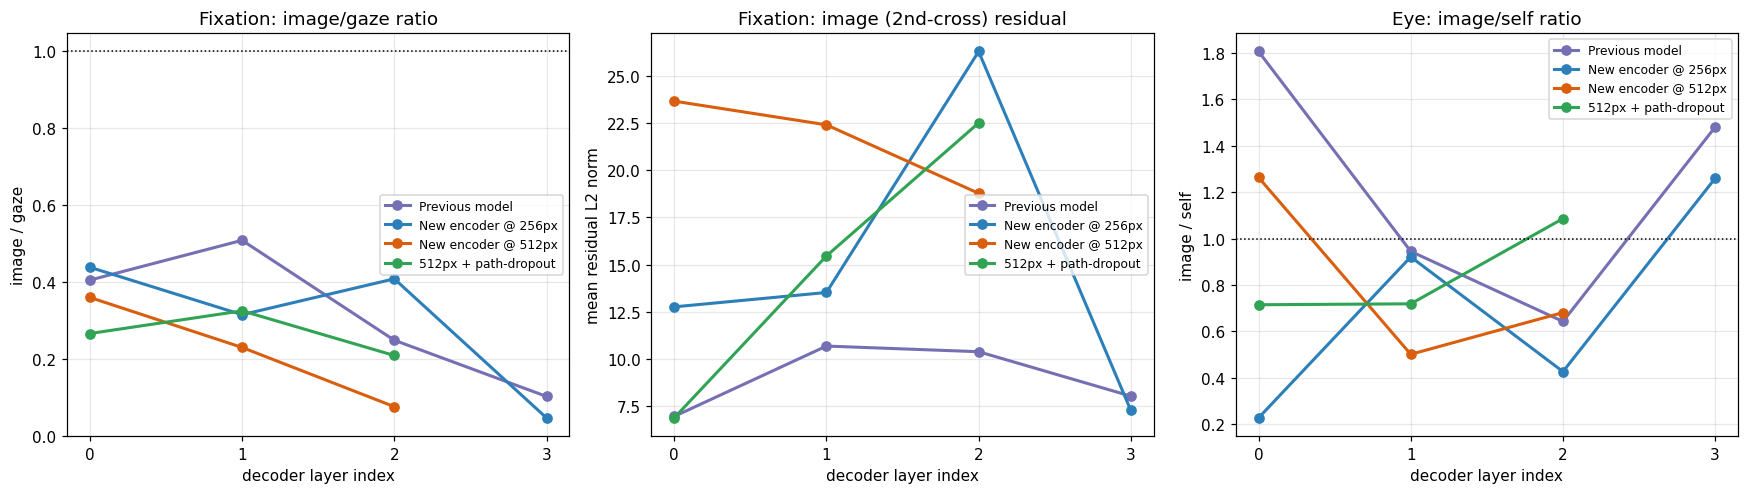

In [35]:
# ── Overlay plots across all versions ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
MAX_L = max(len(v["fix"]["image"]) for v in RES_VERSIONS)

def overlay(ax, getter, title, ylabel):
    for v in RES_VERSIONS:
        y = getter(v); x = np.arange(len(y))
        ax.plot(x, y, marker="o", lw=2, color=COLORS[v["key"]], label=v["label"])
    ax.set_xticks(np.arange(MAX_L)); ax.set_xlabel("decoder layer index")
    ax.set_ylabel(ylabel); ax.set_title(title); ax.legend(fontsize=8)

overlay(axes[0], lambda v: v["fix"]["image"] / v["fix"]["gaze"],
        "Fixation: image/gaze ratio", "image / gaze")
axes[0].axhline(1.0, color="k", ls=":", lw=1)
overlay(axes[1], lambda v: v["fix"]["image"],
        "Fixation: image (2nd-cross) residual", "mean residual L2 norm")
overlay(axes[2], lambda v: v["eye"]["image"] / v["eye"]["self"],
        "Eye: image/self ratio", "image / self")
axes[2].axhline(1.0, color="k", ls=":", lw=1)
plt.tight_layout(); plt.show()

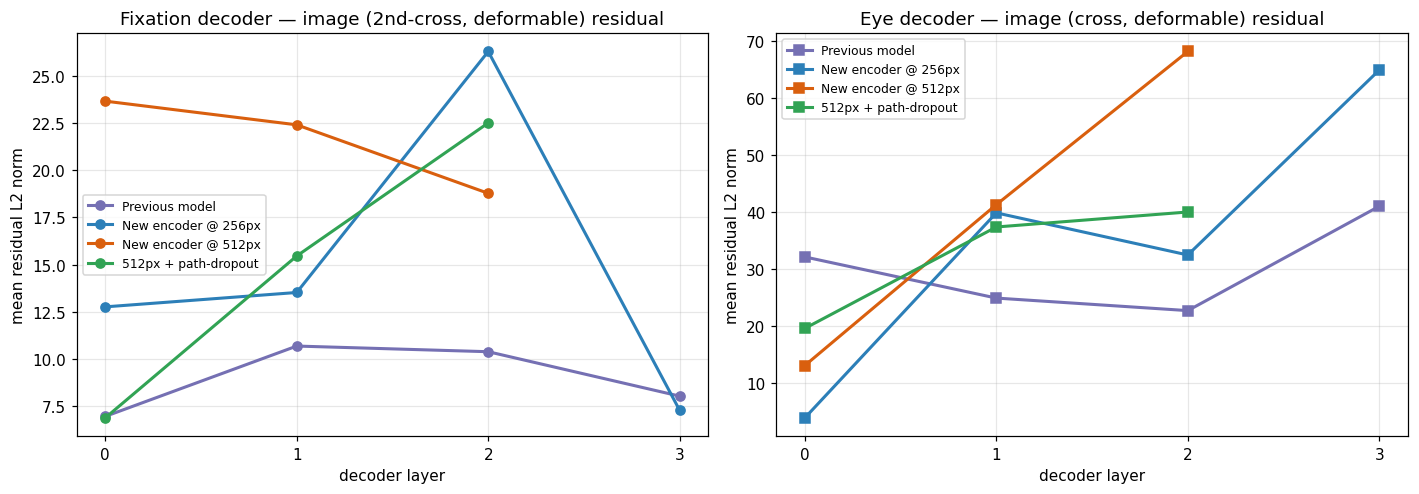

In [ ]:
# ── Focused view: the deformable (image) residual per layer, both decoders, all versions ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
MAX_L = max(v["n_dec"] for v in RES_VERSIONS)
for v in RES_VERSIONS:
    axes[0].plot(np.arange(v["n_dec"]), v["fix"]["image"], marker="o", lw=2,
                 color=COLORS[v["key"]], label=v["label"])
    axes[1].plot(np.arange(v["n_eye"]), v["eye"]["image"], marker="s", lw=2,
                 color=COLORS[v["key"]], label=v["label"])
axes[0].set(xlabel="decoder layer", ylabel="mean residual L2 norm",/create 
            title="Fixation decoder — image (2nd-cross, deformable) residual")
axes[1].set(xlabel="decoder layer", ylabel="mean residual L2 norm",
            title="Eye decoder — image (cross, deformable) residual")
for ax in axes:
    ax.set_xticks(np.arange(MAX_L)); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()